# Past the Tipping Point, Not Yet Transformed

**Exploration notebook · China NEV transition · data vintage 2026-07-12**

Central question: *How quickly is China's dominance of new-energy
vehicles in new-vehicle sales translating into the on-road fleet, and
has charging infrastructure kept pace?*

The notebook keeps annual observations, partial-year observations,
registered fleet stock, and charging connectors in separate tables.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.metrics import cagr, growth_contribution, percent_change, ratio, share
from src.scenarios import scenario_table

DATA = ROOT / "data" / "processed"
annual = pd.read_csv(DATA / "china_auto_market_2015_2025.csv")
fleet = pd.read_csv(DATA / "fleet_charging_snapshot.csv")
pulse = pd.read_csv(DATA / "current_market_pulse.csv")
targets = pd.read_csv(DATA / "policy_targets.csv")

print(f"Loaded {len(annual)} complete annual observations: {annual.year.min()}-{annual.year.max()}")

Loaded 11 complete annual observations: 2015-2025


## 1. Basic mathematics

The core calculations are intentionally transparent:

$$\text{NEV share}_t = \frac{\text{NEV sales}_t}{\text{total automobile sales}_t} \times 100$$

$$\text{YoY growth}_t = \left(\frac{x_t}{x_{t-1}} - 1\right) \times 100$$

$$\text{CAGR} = \left(\frac{x_{end}}{x_{start}}\right)^{1/n} - 1$$

A growth contribution above 100% is possible: it means the growing
component more than explains total net growth while another component
contracted.

In [2]:
annual = annual.assign(
    nev_share_total_sales_pct=lambda x: 100 * x.nev_sales_m / x.total_auto_sales_m,
    nev_sales_yoy_pct=lambda x: x.nev_sales_m.pct_change() * 100,
    non_nev_sales_m=lambda x: x.total_auto_sales_m - x.nev_sales_m,
)

display(
    annual[["year", "total_auto_sales_m", "nev_sales_m", "nev_share_total_sales_pct", "nev_sales_yoy_pct"]]
    .round(2)
    .style.format({
        "total_auto_sales_m": "{:.2f}",
        "nev_sales_m": "{:.2f}",
        "nev_share_total_sales_pct": "{:.1f}%",
        "nev_sales_yoy_pct": "{:.1f}%",
    })
)

,year,total_auto_sales_m,nev_sales_m,nev_share_total_sales_pct,nev_sales_yoy_pct
0,2015,24.60,0.33,1.4%,nan%
1,2016,28.03,0.51,1.8%,53.1%
2,2017,28.88,0.78,2.7%,53.2%
3,2018,28.08,1.26,4.5%,61.6%
4,2019,25.77,1.21,4.7%,-4.0%
5,2020,25.31,1.37,5.4%,13.3%
6,2021,26.28,3.52,13.4%,157.6%
7,2022,26.86,6.89,25.6%,95.6%
8,2023,30.09,9.49,31.6%,37.9%
9,2024,31.44,12.87,40.9%,35.5%


## 2. The first results

The 2025 total-sales share (47.9%) and the separately reported domestic
new-sales share (50.8%) use different denominators. The registered fleet
share (12.0%) is a stock measure. Keeping those definitions visible is
part of the analysis, not a footnote added at the end.

In [3]:
y2024 = annual.loc[annual.year == 2024].iloc[0]
y2025 = annual.loc[annual.year == 2025].iloc[0]
f2025 = fleet.loc[fleet.period == "2025-12-31"].iloc[0]

nev_cagr = cagr(annual.iloc[0].nev_sales_m, y2025.nev_sales_m, 10)
total_share = share(y2025.nev_sales_m, y2025.total_auto_sales_m)
fleet_share = share(f2025.nev_stock_m, f2025.auto_stock_m)
domestic_share = pulse.loc[
    (pulse.period == "2025") & (pulse.scope == "domestic_new_vehicle_sales"),
    "nev_share_reported_pct",
].iloc[0]

total_growth = y2025.total_auto_sales_m - y2024.total_auto_sales_m
nev_growth = y2025.nev_sales_m - y2024.nev_sales_m
non_nev_change = (
    y2025.total_auto_sales_m - y2025.nev_sales_m
    - y2024.total_auto_sales_m + y2024.nev_sales_m
)

summary = pd.DataFrame(
    {
        "Result": [
            "NEV sales CAGR, 2015–2025",
            "NEV share of total CAAM sales, 2025",
            "NEV share of domestic new sales, 2025",
            "NEV share of registered fleet, 2025",
            "Domestic-sales flow minus fleet-stock gap",
            "NEV contribution to 2025 net market growth",
            "Change in non-NEV sales, 2024–2025",
        ],
        "Value": [
            f"{nev_cagr:.1f}%",
            f"{total_share:.1f}%",
            f"{domestic_share:.1f}%",
            f"{fleet_share:.1f}%",
            f"{domestic_share - fleet_share:.1f} pp",
            f"{growth_contribution(nev_growth, total_growth):.1f}%",
            f"{non_nev_change:.2f} million",
        ],
    }
)
display(summary)

,Result,Value
0,"NEV sales CAGR, 2015–2025",47.8%
1,"NEV share of total CAAM sales, 2025",47.9%
2,"NEV share of domestic new sales, 2025",50.8%
3,"NEV share of registered fleet, 2025",12.0%
4,Domestic-sales flow minus fleet-stock gap,38.8 pp
5,NEV contribution to 2025 net market growth,122.3%
6,"Change in non-NEV sales, 2024–2025",-0.66 million


**Interpretation.** NEV sales grew at roughly 47.8% per year across the
decade. In 2025 they generated more than all net automobile-market
growth (122.3%) because estimated non-NEV sales fell by 0.66 million.
This is descriptive accounting, not a causal claim.

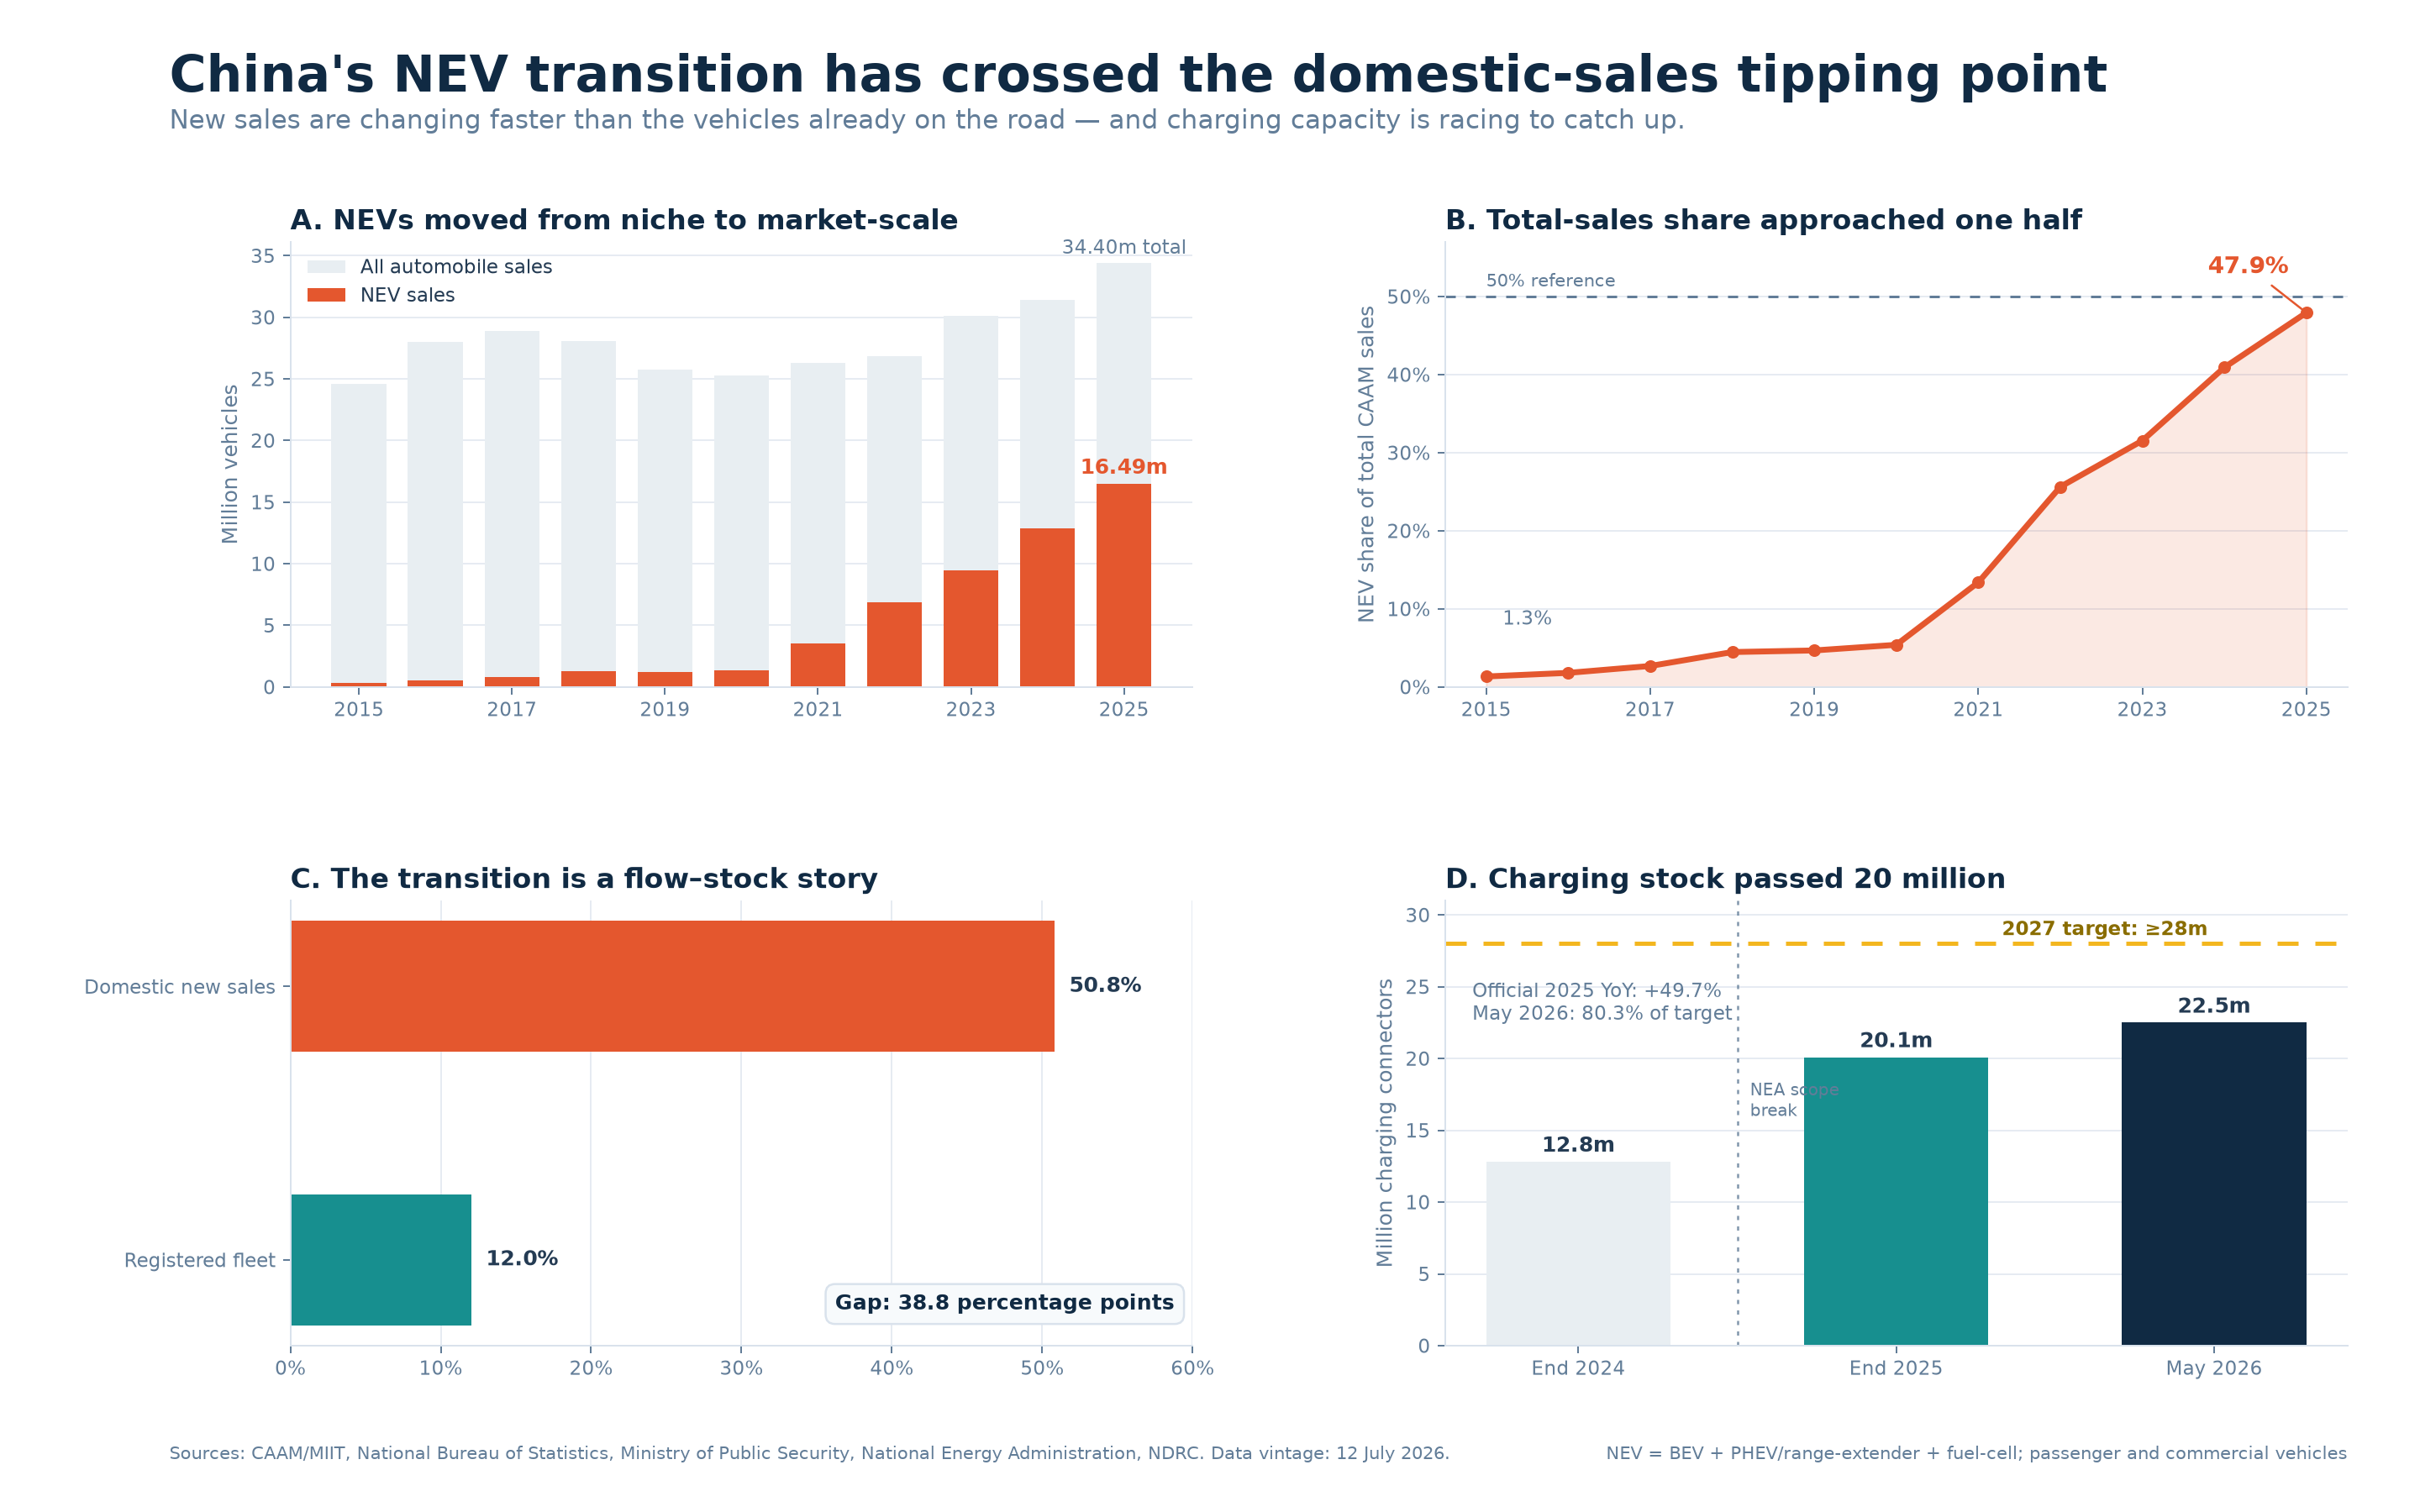

In [4]:
display(Image(filename=str(ROOT / "figures" / "first_look_dashboard.png"), width=1100))

## 3. A bounded scenario, not a confident forecast

A linear extrapolation can exceed 100%, so the scenario uses log-odds:

$$\operatorname{logit}(p_{t+h}) = \operatorname{logit}(p_t) + h g$$

Here $g$ is an explicit annual increment, not an estimated causal
effect. Three values illustrate slower, baseline, and faster paths.

scenario,Baseline,Faster,Slower
year,,,
2025,47.9%,47.9%,47.9%
2026,54.2%,56.6%,51.7%
2027,60.3%,65.0%,55.4%
2028,66.1%,72.5%,59.1%
2029,71.5%,78.9%,62.7%
2030,76.3%,84.1%,66.1%


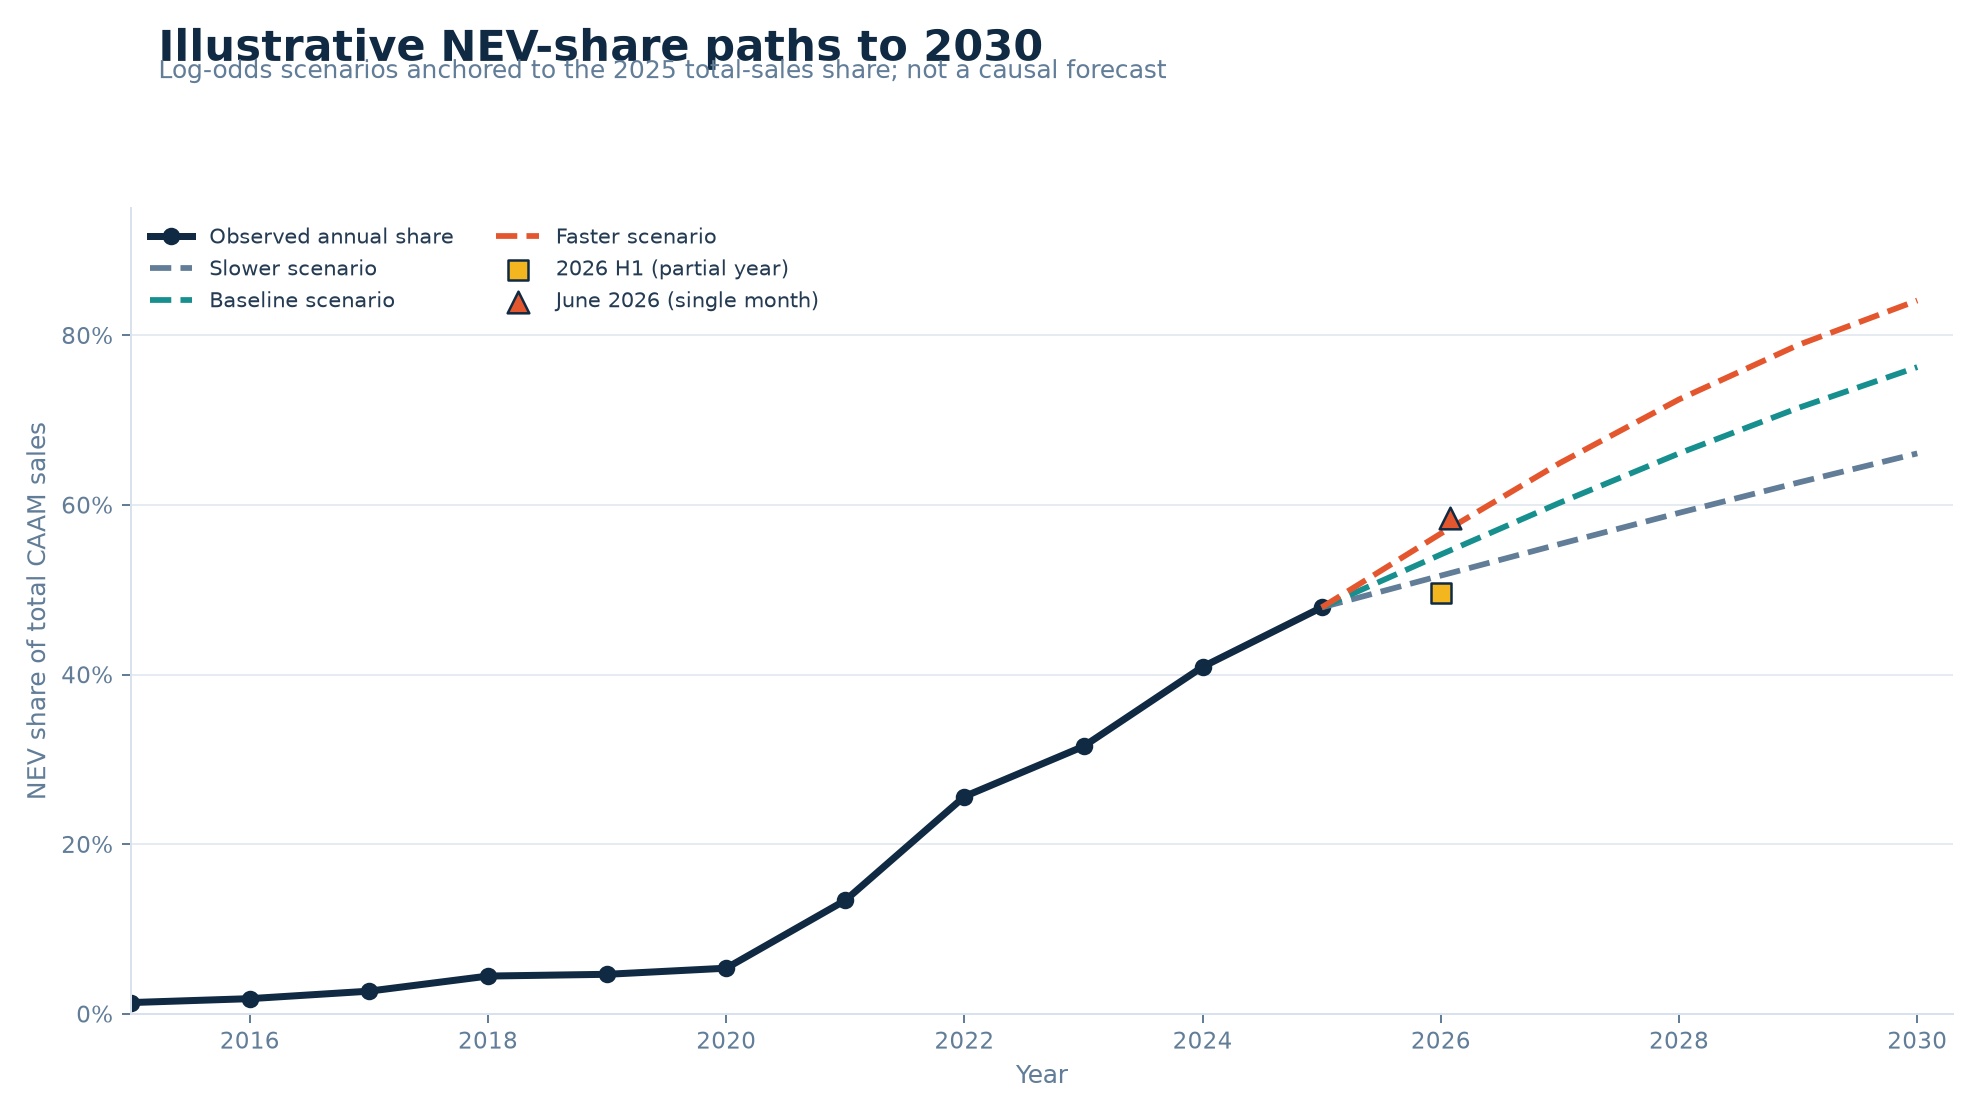

In [5]:
scenarios = scenario_table(
    anchor_year=2025,
    anchor_share=total_share,
    end_year=2030,
    annual_logit_gains={"Slower": 0.15, "Baseline": 0.25, "Faster": 0.35},
)
display(
    scenarios.pivot(index="year", columns="scenario", values="nev_share_pct")
    .round(1)
    .style.format("{:.1f}%")
)
display(Image(filename=str(ROOT / "figures" / "scenario_paths.png"), width=900))

## 4. Limits and next checks

- The pre-2021 annual series was manually transcribed from CAAM charts
  and will receive an independent second-entry audit.
- NEA changed its charging statistical scope in 2025. The 2024 and 2025
  level bars are shown with a visible break; the project uses NEA's
  reported 49.7% YoY rate rather than calculating a misleading rate
  from incompatible endpoints.
- Sales, production, exports, registrations, and fleet stock are not
  interchangeable.
- The 2030 paths are transparent sensitivity scenarios. They are not
  probabilities and do not identify causes.